# **Introduction au Machine Learning et Prétraitement des Données**

---

## **Introduction**

Dans ce notebook, nous allons aborder les bases du Machine Learning, apprendre comment organiser notre travail de manière efficace, et explorer en profondeur les données pour mieux comprendre leur structure et les préparer pour la modélisation.

## **Objectifs**

À la fin de ce notebook, vous serez capable de :
1. Decouvrire les applications du Machine Learning.
2. Organiser votre environnement de travail pour une gestion optimale des données et du code.
3. Explorer et analyser les données pour en tirer des insights initiaux.
4. Appliquer des techniques de prétraitement de données telles que la gestion des valeurs manquantes, l’encodage des variables, la gestion des valeurs aberrantes, la normalisation, et d'autres transformations.

---


## **1. Introduction au Machine Learning**

### Définition

Le **Machine Learning (ML)**, ou apprentissage automatique, est une branche de l'intelligence artificielle qui permet aux machines d'apprendre à partir de données. L’objectif du Machine Learning est de construire des modèles capables de réaliser des tâches spécifiques (comme des prédictions ou des classifications) en analysant des données, sans être explicitement programmés pour chaque tâche.

**Exemples d'applications business** :
- **Prédiction de churn client** : Prédire si un client risque de quitter une entreprise, pour orienter les actions de fidélisation.
- **Scoring de crédit** : Évaluer le risque associé à l’octroi de crédit.
- **Recommandation de produits** : Systèmes de recommandation utilisés par les plateformes e-commerce.

**Question** : 
Pouvez-vous penser à d'autres applications du Machine Learning qui seraient utiles dans le contexte de l’entreprise ?
---

### Workflow Typique de Création d’un Modèle de Machine Learning

Un modèle de Machine Learning suit généralement les étapes suivantes :
1. **Définition de l’objectif** : Identifier la tâche (classification, régression, etc.).
2. **Exploration des données** : Étudier les données disponibles pour comprendre leur structure et leurs caractéristiques.
3. **Prétraitement des données** : Nettoyer et transformer les données pour les rendre exploitables.
4. **Entraînement du modèle** : Choisir et entraîner un algorithme de Machine Learning.
5. **Évaluation et amélioration** : Mesurer les performances du modèle et apporter des améliorations si nécessaire.

---

## **2. Organisation de l’Environnement de Travail**

Pour bien gérer vos données, notebooks, et scripts, il est recommandé d’organiser votre répertoire de travail de manière structurée.

### Structure du Répertoire

Voici une structure recommandée :
- **notebooks/** : Contient les notebooks Jupyter pour chaque module.
- **data/** : Contient les fichiers de données à utiliser dans le projet. Stockez tous les jeux de données ici pour une meilleure organisation.
- **scripts/** : Contient les fichiers `.py` avec des fonctions ou du code réutilisable.

Par exemple, si notre dataset `titanic.csv` est stocké dans le dossier `data` au même niveau que `notebooks`, on peut l’appeler en utilisant le chemin relatif `../data/titanic.csv`.

---

## **3. Exploration des Données**

### Définition

L'**exploration des données** (Exploratory Data Analysis - EDA) est le processus d'examen approfondi d'un jeu de données pour comprendre sa structure, identifier des patterns, et détecter des anomalies ou des valeurs aberrantes. L'objectif de l'EDA est de préparer la base pour les étapes de prétraitement et de modélisation.

### Objectifs de l’Exploration des Données

- **Comprendre la structure des données** : Observer les variables présentes, leur type (numérique, catégoriel) et leur distribution.
- **Identifier les valeurs manquantes et aberrantes** : Détecter les données incomplètes et les valeurs extrêmes, qui peuvent fausser l'analyse.
- **Déterminer les transformations nécessaires** : Décider des étapes de nettoyage et de transformation des données pour rendre les données exploitables.

### Outils et Méthodes Utilisés

Pour l'exploration des données, nous allons utiliser les bibliothèques :
- **Pandas** pour charger et manipuler les données.
- **Matplotlib et Seaborn** pour visualiser les distributions et les relations entre variables.

---

### **Extraction des Données**

Nous allons commencer par charger le dataset `titanic.csv`, qui contient des informations sur les passagers du Titanic.

**Instructions** :
1. Importez les bibliothèques **Pandas** et **NumPy**.
2. Chargez le dataset en utilisant `pd.read_csv()` et affichez les premières lignes avec `.head()` pour voir un aperçu.


In [1]:
# Insérez votre code ici pour charger import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(r"C:\Users\Utilisateur\Desktop\Machine-Learning-Mise-en-pratique\data\titanic.csv")

In [2]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
### Des données numériques mais aussi alphabétiques.

**Question** : En observant les premières lignes du dataset, que représentent les différentes colonnes ? Quels types de données semble-t-il y avoir dans ce dataset (numériques, catégorielles, etc.) ?

---

### **Analyse Exploratoire des Données**

#### 1. **Dimensions et Types de Données** :
   - Utilisez `.shape` pour voir les dimensions du dataset et `.info()` pour obtenir des informations sur les types de données.

In [4]:
df.shape


(891, 12)

In [5]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [6]:
### 891 lignes pour 12 colonnes. Ce n'est pas un immense dataset. 
### On trouve des entiers, des nombres décimaux et du texte. Il est important de connaître les différents type avant de commencer l'analyse
### afin de savoir ce que l'on peut faire comme calcul.

**Questions** :
   - Combien de colonnes et de lignes contient ce dataset ? Qu’est-ce que cela nous indique sur sa taille ?
   - Quels types de données sont présents ? Pourquoi est-il important de connaître les types avant de commencer l’analyse ?

#### 2. **Statistiques Descriptives - Variables Numériques** :
   - Utilisez `.describe()` pour obtenir des statistiques sur les variables numériques (moyenne, écart-type, etc.).


In [7]:
# Insérez votre code ici pour les statistiques descriptives des variables numériques

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
### count → nombre de valeurs présentes.
### mean → moyenne.
### std → écart-type, indique la dispersion des valeurs.
### min → valeur minimale.
### 25% → premier quartile : 25 % des valeurs sont inférieures ou égales.
### 50% → médiane : 50 % des valeurs sont inférieures ou égales.
### 75% → troisième quartile : 75 % des valeurs sont inférieures ou égales.
### max → valeur maximale.

In [9]:
### Fare va de 0 à 512,33 → 512 € est une valeur très élevée par rapport à la médiane de 14,45.
### Age va de 0,42 à 80 → rien d'anormal a priori.
### SibSp va jusqu'à 8 → valeur élevée mais possible.
### Parch va jusqu'à 6 → idem.
### PassengerId n'est pas vraiment une variable à analyser statistiquement : c'est un identifiant.

**Questions** :
   - Que représentent les valeurs de sortie pour chaque statistique ?
   - Pouvez-vous identifier des valeurs extrêmes ou des anomalies potentielles ?


#### 3. **Statistiques Descriptives - Variables Catégorielles** :
   - Utilisez `.describe(include=['O'])` pour obtenir des statistiques descriptives sur les variables catégorielles (type `object`).

In [10]:
# Insérez votre code ici pour les statistiques descriptives des variables catégorielles

df.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [11]:
 ### Name possède 891 catégories uniques, Sex 2, Ticket 681, Cabin 147 et Embarked 3

**Question** : Combien de catégories uniques existe-t-il pour chaque variable catégorielle ? En quoi ces informations pourraient-elles être utiles lors de la modélisation ?

#### 4. **Visualisation des Données**

1. **Visualisation de la Distribution de l'Âge** :
   - Utilisez `sns.histplot()` pour afficher l’histogramme de la distribution de l'âge (`Age`).

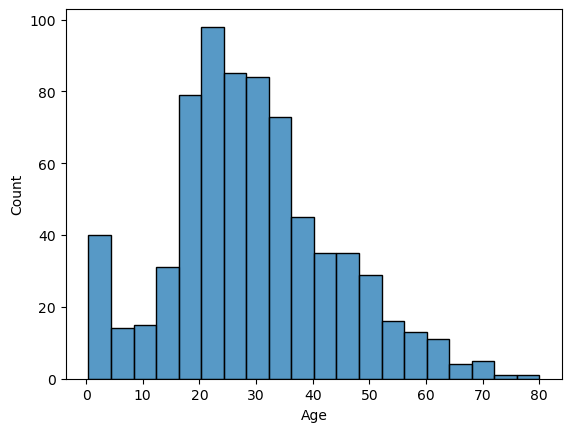

In [12]:
# Insérez votre code ici pour visualiser la distribution de l'âgedf.
sns.histplot(df["Age"])
plt.show()


In [13]:
### Les âges les plus représentés se situent principalement entre 20 et 40 ans, avec une forte présence autour de 20-30 ans.
### La distribution de l’âge peut permettre de mieux comprendre le profil des clients et d'adapter une offre commerciale ou 
### une stratégie marketing selon les tranches d’âge les plus représentées.

**Questions** :
   - Que représente chaque barre de l'histogramme ? Quels âges semblent les plus courants parmi les passagers ?
   - En quoi la distribution de l'âge pourrait-elle influencer une analyse business ?

2. **Visualisation de la Distribution de la variable `Fare`** :
   - Utilisez `sns.histplot()` pour afficher l’histogramme de la distribution de la variable `Fare`.

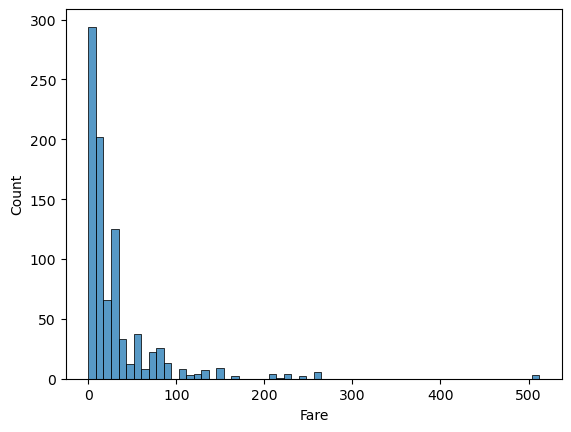

In [14]:
# Insérez votre code ici pour visualiser la distribution de Fare
sns.histplot(df["Fare"])
plt.show()




3. **Corrélations entre Variables Numériques** :

 > **Corrélation** : La corrélation mesure la force et la direction de la relation entre deux variables. Une corrélation proche de 1 ou -1 indique une relation forte, tandis qu'une corrélation proche de 0 indique une relation faible.

   - Utilisez `.corr()` pour calculer la corrélation entre les variables numériques, puis visualisez avec `sns.heatmap()`.

In [15]:
# Insérez votre code ici pour afficher la heatmap de corrdf élations

correlation = df.corr(numeric_only=True)
correlation

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Questions** :
   - Quelles sont les variables fortement corrélées entre elles ? Comment interpréter ces corrélations ?
   - Pourquoi est-il important de connaître les corrélations pour éviter les redondances dans les variables ?

In [16]:

# Pclass et Fare : corrélation négative assez forte. Cela signifie que les passagers des classes 
# les plus élevées ont généralement payé des tarifs plus importants.
# SibSp et Parch : corrélation positive modérée. Les passagers ayant des frères/sœurs ou conjoints 
# à bord avaient plus souvent aussi des parents/enfants à bord.
# Survived et Pclass : corrélation négative. Les passagers des classes supérieures avaient globalement 
# davantage de chances de survivre.

#### 5. **Identification des Valeurs Manquantes**

   - Utilisez `.isnull().sum()` pour identifier les colonnes avec des valeurs manquantes.

In [17]:
# Insérez votre code ici pour vérifier les valeurs manquantes

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
### Colonnes avec valeurs manquantes : Age (177) , Cabin (687), Embarked (2)
### Les valeurs manquantes sont possiblement dûes a des valeurs non renseignées. Celà peut impacter la fiabilité des 
### des résultats du modèle.
    

**Questions** :
   - Quelles colonnes contiennent des valeurs manquantes ? Quelle pourrait être la cause des valeurs manquantes ?
   - Comment le choix de traitement des valeurs manquantes peut-il impacter les résultats d’un modèle ?

#### 6. Gestion des Valeurs Aberrantes (Outliers)

Les valeurs aberrantes (outliers) sont des valeurs extrêmes qui peuvent influencer les résultats de certains modèles. Une méthode simple pour les identifier est l’utilisation d’un **boxplot**.

- **Boxplot pour Identifier les Valeurs Aberrantes** :
   - Utilisez `sns.boxplot()` pour visualiser la distribution de l'âge et de `fare` et identifier les valeurs aberrantes.
   


<Axes: xlabel='Age'>

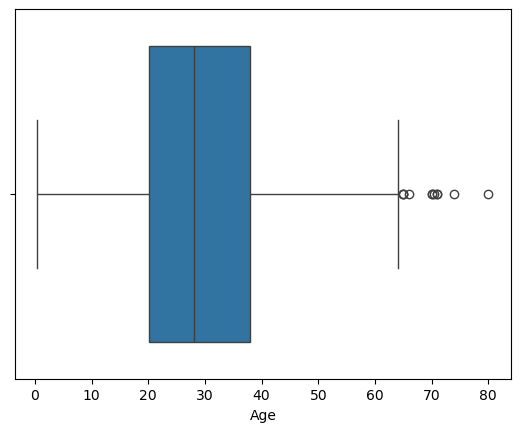

In [19]:
# Insérez votre code ici pour visualiser le boxplot de l'âge
sns.boxplot(x=df["Age"])


<Axes: xlabel='Fare'>

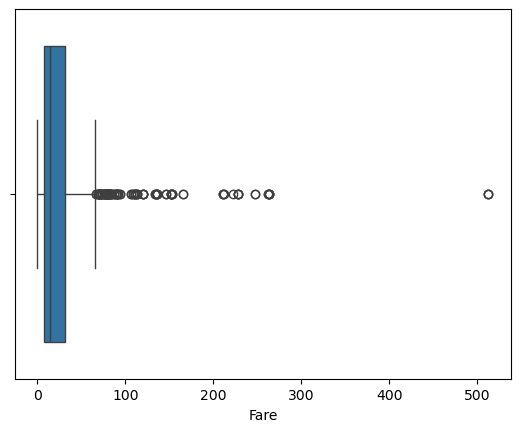

In [20]:
# Insérez votre code ici pour visualiser le boxplot de fare
sns.boxplot(x=df["Fare"])

In [21]:
### . Que représentent les points en dehors des moustaches ?

### Les points situés en dehors des moustaches représentent des valeurs potentiellement aberrantes, 
### c'est-à-dire des valeurs très éloignées de la majorité des données.

### 2. Comment traiter ces valeurs ?

### Il faut d'abord vérifier si ces valeurs sont réellement des erreurs. Si elles sont cohérentes, 
### on peut les conserver. Si elles sont incorrectes, on peut les supprimer ou les remplacer. On peut 
### également les transformer pour limiter leur influence sur le modèle.

**Questions** :
   - Que représentent les points situés en dehors des moustaches du boxplot ? 
   - Comment pourriez-vous traiter ces valeurs aberrantes (les conserver, les supprimer, les transformer) ?

### Résumé de l'Analyse Exploratoire (EDA)

**Instructions** : Rédigez un résumé de vos observations. Notez les points suivants :
   - Les principales caractéristiques du dataset (variables, types de données, etc.).
   - Observations notables, comme les distributions de variables ou des corrélations importantes.
   - Quels aspects du dataset pourraient nécessiter des étapes de nettoyage et de transformation avant la modélisation.
   - ...

---

In [22]:
### Le dataset Titanic contient 891 passagers et 12 variables, avec des données numériques (Age, Fare, Pclass, etc.)
### et catégorielles (Name, Sex, Cabin, Embarked, etc.).

### L'analyse montre que les passagers sont principalement âgés de 20 à 40 ans. Certaines corrélations sont intéressantes, 
### notamment entre Pclass et Fare, ainsi qu'entre SibSp et Parch. La classe du passager semble également liée à la survie.

### Plusieurs étapes de nettoyage seront nécessaires avant la modélisation. Il faudra notamment traiter les valeurs manquantes 
### de Age, Cabin et Embarked, transformer les variables catégorielles en données numériques et vérifier les valeurs aberrantes, notamment dans Fare.

### Ces étapes permettront d'obtenir des données propres et adaptées à la création d'un modèle de Machine Learning.

## **4. Prétraitement des Données**

### Définition

Le **prétraitement des données** consiste à préparer les données pour l’entraînement du modèle. Il inclut le nettoyage des données, le traitement des valeurs manquantes, l’encodage des variables catégorielles, la gestion des valeurs aberrantes, et la normalisation.

### Objectifs du Prétraitement des Données

- **Assurer la qualité des données** : Traiter les valeurs manquantes et aberrantes pour éviter des biais dans les modèles.
- **Préparer les données pour les algorithmes** : Rendre les données exploitables pour le modèle choisi, en appliquant des transformations adaptées.

### Étapes du Prétraitement

---

### 1. Gestion des Valeurs Manquantes

La gestion des valeurs manquantes est essentielle pour garantir la qualité des données avant toute analyse ou modélisation. Les valeurs manquantes peuvent être traitées de différentes manières en fonction du type de variable et de la distribution des données. Voici les stratégies d’imputation couramment utilisées :

- **Moyenne** : Pour les variables continues avec une distribution symétrique et sans valeurs extrêmes.
- **Médiane** : Pour les variables continues susceptibles de contenir des valeurs extrêmes, car elle est moins sensible aux valeurs aberrantes.
- **Mode** : Pour les variables catégorielles, en remplaçant les valeurs manquantes par la catégorie la plus fréquente.
- **Suppression** : Pour les colonnes ayant plus de 70 % de valeurs manquantes, car elles contiennent peu d’informations exploitables.
- **Méthodes avancées** : Dans certains cas, des modèles de Machine Learning peuvent prédire les valeurs manquantes, mais cela nécessite des ressources supplémentaires et une analyse approfondie.

#### **Exemple d’Imputation pour la Colonne `Age`**

Pour la colonne `Age`, nous utilisons la **médiane** pour remplacer les valeurs manquantes, car cette variable continue contient des valeurs extrêmes. Utilisez `.fillna()` pour remplacer les valeurs manquantes


In [23]:
# Insérez votre code ici pour remplir les valeurs manquantes dans la colonne Age

mediane_age = df["Age"].median()

df["Age"] = df["Age"].fillna(mediane_age)


In [24]:
df["Age"].isnull().sum()




np.int64(0)

**Question** : 
- Pourquoi utiliser la médiane peut-il être plus avantageux que la moyenne pour remplacer les valeurs manquantes ?

In [25]:
### Parce que la médiane est moins influencée par les valeurs extrêmes que la moyenne.

#### **Application des Stratégies pour les Autres Variables**

Pour les autres variables, choisissez la stratégie d’imputation appropriée selon la nature de la colonne :

- Utilisez la **moyenne** ou la **médiane** pour les variables continues, selon la présence de valeurs extrêmes.
- Utilisez le **mode** pour les variables catégorielles.
- Supprimez les colonnes avec un grand nombre de valeurs manquantes si elles contiennent plus de 70 % de données manquantes.

**Questions** :
- Quels sont les avantages et inconvénients d'utiliser la moyenne, la médiane ou le mode pour gérer les valeurs manquantes ?

---
### 2. **Calcule et Traitement des Valeurs Aberrantes avec la methode de l'IQR**

Une fois que nous avons identifié des valeurs aberrantes lors de l'exploration des données, nous pouvons maintenant les traiter dans la phase de prétraitement. Les valeurs aberrantes sont des observations extrêmes qui se situent en dehors de la majorité des données et peuvent affecter la performance de certains modèles de Machine Learning.

#### **Méthode de l'IQR pour le Traitement des Valeurs Aberrantes**

Pour repérer les valeurs aberrantes de manière quantitative, nous utilisons l'Intervalle Interquartile (`IQR`). En rappel, l'IQR est défini comme la différence entre le troisième quartile (`Q3`) et le premier quartile (`Q1`) : $IQR = Q3 - Q1$

Pour identifier les valeurs aberrantes, on utilise les bornes suivantes :
- **Borne inférieure** : $ Q1 - 1.5 \times IQR $
- **Borne supérieure** : $ Q3 + 1.5 \times IQR $

Les valeurs en dehors de cet intervalle sont considérées comme aberrantes.

##### **Étapes pour Traiter les Valeurs Aberrantes**

1. **Calcul des Quartiles et de l'IQR** :
   - Calculez les quartiles  `Q1` et `Q3`  pour les variables `Age` et `Fare`.
   - Déterminez l'IQR en soustrayant `Q1` de `Q3`.

2. **Détection des Valeurs Aberrantes** :
   - Calculez les bornes inférieure et supérieure pour chaque variable.
   - Filtrez les valeurs de `Age` et `Fare` qui se trouvent en dehors de ces bornes.

3. **Options pour le Traitement** :
   - **Suppression** : Supprimer les valeurs aberrantes si elles sont peu nombreuses et qu'elles risquent d'affecter le modèle.
   - **Transformation** : Appliquer une transformation (comme la transformation logarithmique) pour réduire l’impact des valeurs extrêmes.
   - **Imputation** : Remplacer les valeurs aberrantes par la médiane ou un autre résumé statistique si elles sont essentielles pour l’analyse.

**Instructions** :
- Calculez les valeurs de `Q1`, `Q3` et `IQR` pour `Age` et `Fare`.
- Déterminez les bornes pour filtrer les valeurs aberrantes et décidez comment les traiter en fonction du contexte.

In [26]:
# Insérez votre code ici pour détection des Valeurs Aberrantes de l'age et de face
# Calcul pour Age
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

print("Q1 Age :", Q1_age)
print("Q3 Age :", Q3_age)
print("IQR Age :", IQR_age)

#Calcul pour Fare 

Q1_fare = df["Fare"].quantile(0.25)
Q3_fare = df["Fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

print("Q1 Fare :", Q1_fare)
print("Q3 Fare :", Q3_fare)
print("IQR Fare :", IQR_fare)

Q1 Age : 22.0
Q3 Age : 35.0
IQR Age : 13.0
Q1 Fare : 7.9104
Q3 Fare : 31.0
IQR Fare : 23.0896


In [27]:
### Calcul de bornes 
# Pour Age

borne_inf_age = Q1_age - 1.5 * IQR_age
borne_sup_age = Q3_age + 1.5 * IQR_age

print("Borne inférieure Age :", borne_inf_age)
print("Borne supérieure Age :", borne_sup_age)

# Pour Fare 

borne_inf_fare = Q1_fare - 1.5 * IQR_fare
borne_sup_fare = Q3_fare + 1.5 * IQR_fare

print("Borne inférieure Fare :", borne_inf_fare)
print("Borne supérieure Fare :", borne_sup_fare)


Borne inférieure Age : 2.5
Borne supérieure Age : 54.5
Borne inférieure Fare : -26.724
Borne supérieure Fare : 65.6344


In [28]:
### Valeurs aberrantes

print("Valeurs aberrantes Age :", ((df["Age"] < borne_inf_age) | (df["Age"] > borne_sup_age)).sum())

print("Valeurs aberrantes Fare :", ((df["Fare"] < borne_inf_fare) | (df["Fare"] > borne_sup_fare)).sum())

Valeurs aberrantes Age : 66
Valeurs aberrantes Fare : 116


In [29]:
### Les valeurs aberrantes identifiées dans Age et Fare ne sont pas nécessairement des erreurs. Elles peuvent représenter des situations réelles. 
### Nous choisissons donc de les conserver afin de ne pas perdre d'informations importantes.

**Questions** :
- Quels sont les avantages de transformer ou de supprimer les valeurs aberrantes dans `Age` et `Fare` ?
- Comment ces décisions pourraient-elles influencer les résultats de votre modèle de Machine Learning ?

---

### 3. **Encodage des Variables Catégorielles**

1. **Encodage One-Hot** :
   - Utilisez `pd.get_dummies()` pour encoder les variables catégorielles (`Sex`, `Embarked`) en variables numériques.

In [30]:
# Insérez votre code ici pour encoder les variables catégorielles
df = pd.get_dummies(df, columns=["Sex", "Embarked"], dtype=int)

In [31]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,0,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,1,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,1,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,0,1,0,0,1


**Question** : Comment l’encodage des variables catégorielles peut-il aider certains algorithmes de Machine Learning à mieux traiter les données ?

In [32]:
### L'encodage permet de transformer les données catégorielles en données numériques. C'est important car de nombreux algorithmes 
### de Machine Learning ne peuvent pas travailler directement avec des valeurs textuelles. Le One-Hot Encoding permet également de 
### représenter chaque catégorie sans créer d'ordre artificiel entre elles.

---

### 4. Normalisation et Standardisation des Variables

La **normalisation** et la **standardisation** sont des étapes importantes dans le prétraitement des données pour s’assurer que toutes les variables sont sur une même échelle. Cela évite que certaines variables, qui ont des valeurs plus grandes ou plus petites, influencent davantage le modèle que d'autres, simplement à cause de leur amplitude.

- **Normalisation** : La normalisation consiste à rescaler les données pour qu’elles soient comprises entre 0 et 1. Cela est utile lorsque les données contiennent des valeurs de tailles très différentes. Par exemple, si l’une des variables représente des montants financiers en milliers et qu'une autre représente des pourcentages, la normalisation permet de placer ces deux variables sur une échelle de 0 à 1, ce qui facilite les calculs et rend les valeurs comparables.

  Formule de la normalisation : $ x_{\text{norm}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$

- **Standardisation** : La standardisation consiste à transformer les données pour qu’elles aient une moyenne de 0 et un écart-type de 1. Cette méthode est utile lorsque les valeurs sont distribuées autour d’une moyenne mais avec des écarts variés. La standardisation centre les données autour de 0, ce qui aide à équilibrer leur influence dans les calculs du modèle.

  Formule de la standardisation :
  $ z = \frac{x - \mu}{\sigma}$, où $ \mu $ est la moyenne de la variable et $ \sigma $ est son écart-type.

**Pourquoi normaliser ou standardiser ?**  
Ces transformations sont appliquées pour que les variables aient une échelle comparable, ce qui permet d’éviter que certaines variables dominent les calculs simplement en raison de leur amplitude. Cela peut aussi améliorer la performance des modèles de Machine Learning qui sont sensibles aux différences d’échelle entre les variables, comme les modèles de distances.

##### **Instructions pour Appliquer la Normalisation et la Standardisation**

- **Normalisation** : Utilisez `MinMaxScaler` de `sklearn.preprocessing` pour transformer les variables numériques afin qu’elles soient comprises entre 0 et 1.

In [33]:
# Insérez votre code ici pour normalisation les variables numériques


variables = ["Age", "Fare"]
scaler = MinMaxScaler()

In [34]:
df[["Age_norm", "Fare_norm"]] = scaler.fit_transform(df[variables])

**Question** : Question : Pourquoi la normalisation pourrait-elle être utile pour certains types d’analyses ?

In [35]:
### La normalisation permet de mettre les variables numériques sur une même échelle, entre 0 et 1. Cela évite qu'
### une variable avec de grandes valeurs, comme Fare, ait trop d'influence par rapport aux autres variables. Elle 
### peut donc améliorer les performances de certains algorithmes de Machine Learning.

- **Standardisation** : Utilisez `StandardScaler` de `sklearn.preprocessing` pour transformer les variables numériques afin qu’elles aient une moyenne de 0 et un écart-type de 1.

In [36]:
# Insérez votre code icfrom sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age_sdt", "Fare_sdt"]] = scaler.fit_transform(df[variables])

**Question** : Dans quel cas pensez-vous que la standardisation des données pourrait être importante ?

In [37]:
### La standardisation est importante lorsque les variables ont des échelles ou des unités très différentes. 
### Elle permet de les ramener autour d'une moyenne de 0 avec un écart-type de 1, afin qu'aucune variable ne 
### domine les autres. Elle est particulièrement utile pour les algorithmes sensibles à l'échelle des données.

---
### Feature Engineering

Créer de nouvelles variables à partir des données existantes peut améliorer les performances du modèle. Par exemple :
   - **Membre de Famille** : Combinez `SibSp` (nombre de frères/sœurs/époux) et `Parch` (nombre de parents/enfants) pour créer une nouvelle variable représentant le nombre total de membres de la famille.

In [38]:
# Insérez votre code ici pour créer la variable Membre de Famille
df["Membre_de_Famille"] = df["SibSp"] + df["Parch"]

In [39]:
df[["SibSp", "Parch", "Membre_de_Famille"]].head()

,SibSp,Parch,Membre_de_Famille
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


**Question** : Comment l’ajout de cette nouvelle variable pourrait-il aider un modèle de Machine Learning à mieux prédire la survie ?

In [40]:
### Cette nouvelle variable regroupe les informations sur les frères, sœurs, conjoints, parents et enfants. 
### Elle peut aider le modèle à mieux identifier l'influence de la taille de la famille sur les chances 
### de survie d'un passager.

### Autres Étapes de Prétraitement

D'autres transformations peuvent être nécessaires selon les besoins :
   - **Transformation de l'âge en groupes d'âge** : Regroupez la colonne `Age` en catégories comme "Enfant", "Adolescent", "Adulte", "Senior".
   - **Transformation logarithmique** : Réduisez l'impact des valeurs extrêmes en appliquant une transformation logarithmique. Par exemple, appliquez `np.log1p()` sur la colonne `Fare`.

In [41]:
# Insérez votre code ici pour les transformations supplémentaires et la visualisation avant/après

# Remplacer les âges manquants
df["Age"] = df["Age"].fillna(df["Age"].median())

# Créer les groupes d'âge
df["Groupe_Age"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 60, 100],
    labels=["Enfant", "Adolescent", "Adulte", "Senior"]
)

# Transformation logarithmique de Fare
df["Fare_log"] = np.log1p(df["Fare"])

In [42]:
df[["Age", "Groupe_Age"]].head()

,Age,Groupe_Age
0,22.0,Adulte
1,38.0,Adulte
2,26.0,Adulte
3,35.0,Adulte
4,35.0,Adulte


In [43]:
df["Fare_log"] = np.log1p(df["Fare"])
print(df[["Fare", "Fare_log"]].head())

      Fare  Fare_log
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765


**Conversions des Transformations** :
   - **Binning (ou catégorisation)** : Transformer des variables continues comme l'âge en groupes d'âge.
   - **Log transformation** : Appliquée sur des valeurs numériques étendues pour en réduire la dispersion.

**Question** : Comment ces transformations peuvent-elles affecter la distribution des données ? Dans quel cas sont-elles nécessaires ?

In [ ]:
### Le binning regroupe les valeurs en catégories, ce qui simplifie l'analyse mais réduit la précision. La transformation 
### logarithmique réduit l'influence des valeurs extrêmes. Ces transformations sont utiles lorsque les données sont très dispersées 
### ou contiennent des valeurs élevées.

---

## **Résumé et Conclusion**

Dans ce module, vous avez appris :
- Découvert les applications du Machine Learning en entreprise.
- L'importance de l'exploration des données et les outils pour l'EDA.
- Les techniques de prétraitement des données : gestion des valeurs manquantes, encodage, normalisation, valeurs aberrantes, et **feature engineering**.

Ces compétences sont cruciales pour préparer des données prêtes pour la modélisation en Machine Learning.